# RQ1: Individual Influential Factors in Trend Classification

**Research question:** What factors, such as platform, region, content category, traffic source, and engagement metrics, most strongly influence video trend classification?

This notebook focuses on **individual features**, not feature groups. RQ2 handles group-level experiments. Here, each original column is evaluated as its own candidate factor so we can discuss specific variables such as `platform`, `region`, `category`, `traffic_source`, `views`, `shares`, or `completion_rate`.

The analysis uses three complementary views:

1. **Single-feature models:** how well each feature predicts `trend_label` by itself.
2. **Permutation importance:** how much an all-feature model depends on each feature.
3. **Logistic coefficient strength:** which encoded feature columns receive larger linear-model weights.

The original processed dataset is used because its columns are transparent and interpretable. The ML-ready CSV is not used for the main RQ1 analysis because its engineered columns may be too close to the target construction.

## 1. Experiment Setup

In [17]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.api.types import is_bool_dtype, is_object_dtype, is_string_dtype
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_CSV = DATA_DIR / "train.csv"
VALIDATION_CSV = DATA_DIR / "validation.csv"
TEST_CSV = DATA_DIR / "test.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", DATA_DIR)

Project root: c:\Users\ZXIA3\IML_A2
Processed data directory: c:\Users\ZXIA3\IML_A2\data\processed


## 2. Load Data

The existing preprocessing split is used so RQ1, RQ2, and RQ3 remain comparable.

In [18]:
train = pd.read_csv(TRAIN_CSV)
validation = pd.read_csv(VALIDATION_CSV)
test = pd.read_csv(TEST_CSV)

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]
X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]
X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "columns": train.shape[1]},
    {"split": "validation", "rows": len(validation), "columns": validation.shape[1]},
    {"split": "test", "rows": len(test), "columns": test.shape[1]},
])

display(split_summary)
display(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).round(4))

,split,rows,columns
0,train,33655,46
1,validation,7212,46
2,test,7212,46


,train,validation,test
trend_label,,,
declining,0.2497,0.2496,0.2497
rising,0.2517,0.2518,0.2517
seasonal,0.2526,0.2526,0.2526
stable,0.2460,0.2460,0.2460


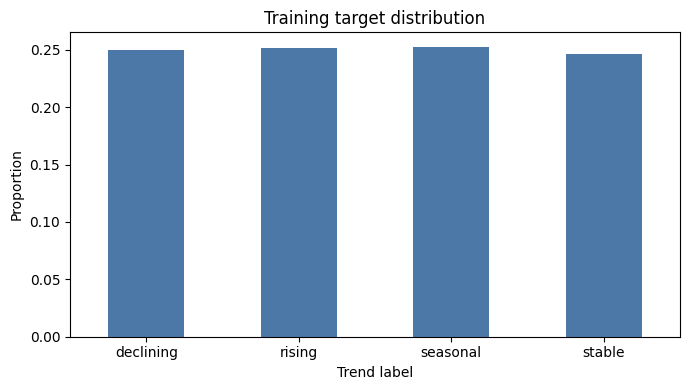

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
y_train.value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Training target distribution")
ax.set_ylabel("Proportion")
ax.set_xlabel("Trend label")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

## 3. Feature Inventory

Before modelling, list each candidate feature with its type, missingness, and number of unique values. This keeps RQ1 grounded in individual columns rather than broad groups.

In [20]:
def is_categorical(series: pd.Series) -> bool:
    return (
        is_object_dtype(series)
        or is_string_dtype(series)
        or is_bool_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    )


feature_inventory = pd.DataFrame([
    {
        "feature": column,
        "kind": "categorical" if is_categorical(X_train[column]) else "numeric",
        "dtype": str(X_train[column].dtype),
        "missing_rate": X_train[column].isna().mean(),
        "n_unique": X_train[column].nunique(dropna=True),
    }
    for column in X_train.columns
]).sort_values(["kind", "feature"])

display(feature_inventory.round(4))

,feature,kind,dtype,missing_rate,n_unique
4,category,categorical,str,0.0,19
1,country,categorical,str,0.0,30
27,creator_tier,categorical,str,0.0,2
33,device_brand,categorical,str,0.0,9
15,device_type,categorical,str,0.0,3
25,event_season,categorical,str,0.0,5
17,genre,categorical,str,0.0,14
5,hashtag,categorical,str,0.0,41
3,language,categorical,str,0.0,19
0,platform,categorical,str,0.0,2


## 4. Modelling Helpers

In [21]:
def split_column_types(X: pd.DataFrame):
    categorical_cols = [col for col in X.columns if is_categorical(X[col])]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    return categorical_cols, numeric_cols


def make_preprocessor(X: pd.DataFrame, scale_numeric: bool = False):
    categorical_cols, numeric_cols = split_column_types(X)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False)),
    ])

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_transformer = Pipeline(steps=numeric_steps)

    return ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_cols),
            ("num", numeric_transformer, numeric_cols),
        ],
        verbose_feature_names_out=False,
    )


def make_logistic_pipeline(X: pd.DataFrame):
    return Pipeline(steps=[
        ("preprocess", make_preprocessor(X, scale_numeric=True)),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            C=0.5,
            random_state=RANDOM_STATE,
        )),
    ])


def make_random_forest_pipeline(X: pd.DataFrame, n_estimators: int = 160):
    return Pipeline(steps=[
        ("preprocess", make_preprocessor(X, scale_numeric=False)),
        ("model", RandomForestClassifier(
            n_estimators=n_estimators,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])


def evaluate_classifier(model, X, y, label: str) -> dict:
    predictions = model.predict(X)
    return {
        "split": label,
        "accuracy": accuracy_score(y, predictions),
        "macro_f1": f1_score(y, predictions, average="macro"),
    }

## 5. Baseline Model Quality

The classes are close to balanced, so a useful model should improve macro-F1 beyond the chance-level region around 0.25. This section gives context for interpreting all individual-feature rankings.

In [22]:
models = {
    "majority_baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_regression_all_features": make_logistic_pipeline(X_train),
    "random_forest_all_features": make_random_forest_pipeline(X_train, n_estimators=160),
}

model_scores = []
fitted_models = {}

for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    fitted_models[name] = fitted
    for split_name, X, y in [
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        row = evaluate_classifier(fitted, X, y, split_name)
        row["model"] = name
        model_scores.append(row)

model_scores = pd.DataFrame(model_scores)[["model", "split", "accuracy", "macro_f1"]]
display(model_scores.sort_values(["split", "macro_f1"], ascending=[True, False]).round(4))

,model,split,accuracy,macro_f1
5,random_forest_all_features,test,0.2481,0.2481
3,logistic_regression_all_features,test,0.2481,0.2480
1,majority_baseline,test,0.2526,0.1008
4,random_forest_all_features,validation,0.2555,0.2555
2,logistic_regression_all_features,validation,0.2402,0.2399
0,majority_baseline,validation,0.2526,0.1008


              precision    recall  f1-score   support

   declining      0.256     0.247     0.252      1800
      rising      0.242     0.245     0.244      1816
    seasonal      0.269     0.275     0.272      1822
      stable      0.255     0.255     0.255      1774

    accuracy                          0.256      7212
   macro avg      0.256     0.256     0.255      7212
weighted avg      0.256     0.256     0.256      7212



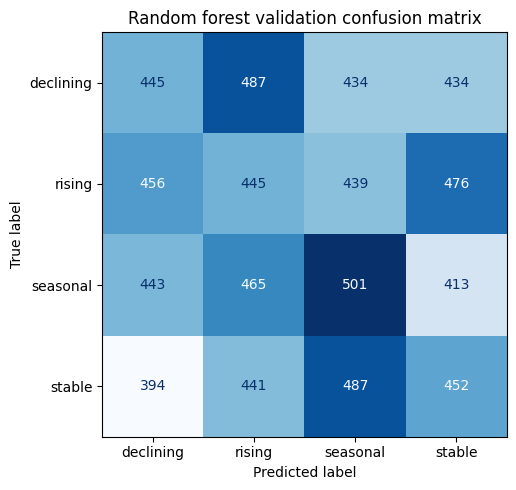

In [23]:
rf_model = fitted_models["random_forest_all_features"]
rf_val_predictions = rf_model.predict(X_val)

print(classification_report(y_val, rf_val_predictions, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, rf_val_predictions, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random forest validation confusion matrix")
plt.tight_layout()

## 6. Single-feature Predictive Strength

Each feature is used by itself to predict `trend_label`. This is the clearest individual-factor test: if a variable is influential on its own, a one-feature model should perform better than chance-level behaviour.

In [24]:
def fit_single_feature_model(feature: str, model_name: str):
    X_train_one = X_train[[feature]]
    X_val_one = X_val[[feature]]

    if model_name == "logistic_regression":
        model = make_logistic_pipeline(X_train_one)
    elif model_name == "random_forest":
        model = make_random_forest_pipeline(X_train_one, n_estimators=80)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    start = time.time()
    fitted = model.fit(X_train_one, y_train)
    predictions = fitted.predict(X_val_one)
    return {
        "feature": feature,
        "model": model_name,
        "accuracy": accuracy_score(y_val, predictions),
        "macro_f1": f1_score(y_val, predictions, average="macro"),
        "fit_seconds": time.time() - start,
    }


single_feature_rows = []
for feature in X_train.columns:
    for model_name in ["logistic_regression", "random_forest"]:
        single_feature_rows.append(fit_single_feature_model(feature, model_name))

single_feature_results = pd.DataFrame(single_feature_rows)
single_feature_wide = (
    single_feature_results
    .pivot(index="feature", columns="model", values=["accuracy", "macro_f1"])
)
single_feature_wide.columns = [f"{metric}_{model}" for metric, model in single_feature_wide.columns]
single_feature_wide = single_feature_wide.reset_index()
single_feature_wide["best_single_feature_macro_f1"] = single_feature_wide[
    ["macro_f1_logistic_regression", "macro_f1_random_forest"]
].max(axis=1)

single_feature_ranked = single_feature_wide.sort_values("best_single_feature_macro_f1", ascending=False)
display(single_feature_ranked.head(25).round(4))

,feature,accuracy_logistic_regression,accuracy_random_forest,macro_f1_logistic_regression,macro_f1_random_forest,best_single_feature_macro_f1
26,like_rate,0.2494,0.2573,0.1677,0.2573,0.2573
14,engagement_like_rate,0.2494,0.2564,0.1677,0.2564,0.2564
16,engagement_rate,0.2503,0.2557,0.1684,0.2557,0.2557
15,engagement_per_1k,0.2503,0.2544,0.1684,0.2544,0.2544
38,shares,0.2442,0.2543,0.1578,0.2542,0.2542
27,likes,0.2436,0.2518,0.1585,0.2516,0.2516
13,engagement_comment_rate,0.2492,0.2512,0.1670,0.2512,0.2512
10,dislike_rate,0.2546,0.2508,0.1709,0.2507,0.2507
24,language,0.2515,0.2514,0.2499,0.2503,0.2503
29,publish_day,0.2514,0.2506,0.1680,0.2492,0.2492


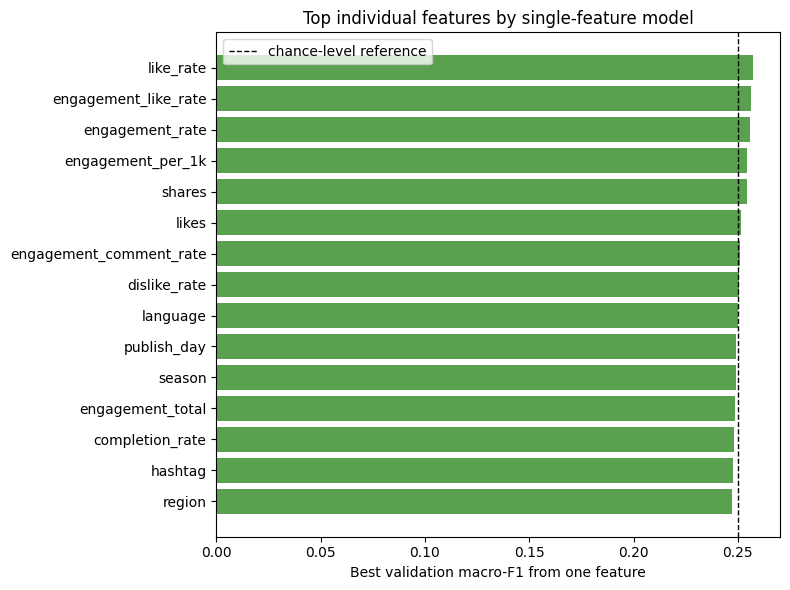

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
top_single = single_feature_ranked.head(15).sort_values("best_single_feature_macro_f1")
ax.barh(top_single["feature"], top_single["best_single_feature_macro_f1"], color="#59A14F")
ax.axvline(0.25, color="black", linestyle="--", linewidth=1, label="chance-level reference")
ax.set_xlabel("Best validation macro-F1 from one feature")
ax.set_ylabel("")
ax.set_title("Top individual features by single-feature model")
ax.legend()
plt.tight_layout()

## 7. Individual Permutation Importance

Permutation importance measures how much validation macro-F1 changes when one feature is shuffled in the all-feature random forest. This captures individual dependence inside a multivariate model.

In [26]:
permutation = permutation_importance(
    rf_model,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame({
        "feature": X_val.columns,
        "macro_f1_drop_mean": permutation.importances_mean,
        "macro_f1_drop_std": permutation.importances_std,
    })
    .sort_values("macro_f1_drop_mean", ascending=False)
)

display(permutation_importance_df.head(25).round(4))

,feature,macro_f1_drop_mean,macro_f1_drop_std
20,share_rate,0.0051,0.0031
29,title_length,0.0043,0.0027
13,saves,0.0039,0.0030
33,device_brand,0.0036,0.0019
18,dislikes,0.0036,0.0025
43,publish_month,0.0033,0.0017
36,engagement_total,0.0032,0.0026
32,completion_rate,0.0027,0.0013
9,views,0.0023,0.0028
3,language,0.0023,0.0019


## 8. Logistic Coefficient Strength

The logistic model is weaker than the random forest but more inspectable. The table below aggregates mean absolute coefficient values from encoded columns back to original feature names.

In [29]:
logistic_model = fitted_models["logistic_regression_all_features"]
coefficient_strength = np.abs(logistic_model.named_steps["model"].coef_).mean(axis=0)

logistic_importance = aggregate_encoded_values_to_original_features(
    logistic_model,
    X_train,
    coefficient_strength,
    "mean_abs_logistic_coefficient",
)

display(logistic_importance.head(25).round(4))

,feature,mean_abs_logistic_coefficient
22,hashtag,3.1030
5,country,0.7735
20,genre,0.7143
1,category,0.6072
24,language,0.3655
8,device_brand,0.3324
7,creator_tier,0.2602
41,traffic_source,0.1595
30,publish_dayofweek,0.1513
19,event_season,0.0883


## 9. Combined Individual-feature Ranking

The combined table joins the individual rankings. Features that appear near the top across several columns are more defensible RQ1 candidates than features that rank highly in only one model-specific view.

In [30]:
combined_importance = (
    feature_inventory[["feature", "kind", "n_unique"]]
    .merge(single_feature_ranked[[
        "feature",
        "macro_f1_logistic_regression",
        "macro_f1_random_forest",
        "best_single_feature_macro_f1",
    ]], on="feature", how="left")
    .merge(permutation_importance_df, on="feature", how="left")
    .merge(rf_impurity_importance, on="feature", how="left")
    .merge(logistic_importance, on="feature", how="left")
)

rank_columns = [
    "best_single_feature_macro_f1",
    "macro_f1_drop_mean",
    "rf_impurity_importance",
    "mean_abs_logistic_coefficient",
]

for column in rank_columns:
    combined_importance[f"rank_{column}"] = combined_importance[column].rank(ascending=False, method="average")

combined_importance["mean_rank"] = combined_importance[[f"rank_{column}" for column in rank_columns]].mean(axis=1)
combined_importance = combined_importance.sort_values("mean_rank")

display(combined_importance[[
    "feature", "kind", "n_unique",
    "best_single_feature_macro_f1",
    "macro_f1_drop_mean",
    "rf_impurity_importance",
    "mean_abs_logistic_coefficient",
    "mean_rank",
]].head(25).round(4))

,feature,kind,n_unique,best_single_feature_macro_f1,macro_f1_drop_mean,rf_impurity_importance,mean_abs_logistic_coefficient,mean_rank
19,completion_rate,numeric,451,0.2483,0.0027,0.0327,0.0278,12.50
16,avg_watch_time_sec,numeric,632,0.2454,0.0013,0.0322,0.0576,13.50
40,shares,numeric,3013,0.2542,0.0007,0.0291,0.0418,15.00
43,views,numeric,30487,0.2467,0.0023,0.0294,0.0313,15.00
8,language,categorical,19,0.2503,0.0023,0.0141,0.3655,15.25
24,engagement_comment_rate,numeric,33491,0.2512,0.0018,0.0310,0.0100,15.75
29,engagement_total,numeric,14498,0.2487,0.0032,0.0290,0.0206,16.00
34,likes,numeric,12515,0.2516,0.0004,0.0291,0.0325,16.75
38,saves,numeric,3232,0.2394,0.0039,0.0302,0.0312,17.00
21,dislike_rate,numeric,6375,0.2507,0.0014,0.0316,0.0069,17.25


## 10. Features Named in the Research Question

This table extracts the specific examples named in RQ1: platform, region, content category, traffic source, and engagement metrics. It helps separate the report discussion from whichever features happen to rank highest overall.

In [31]:
rq1_named_features = [
    "platform", "region", "country", "language", "category", "genre", "traffic_source",
    "views", "likes", "comments", "shares", "saves", "engagement_rate",
    "comment_ratio", "share_rate", "save_rate", "completion_rate", "avg_watch_time_sec",
]

rq1_named_table = combined_importance[combined_importance["feature"].isin(rq1_named_features)].copy()
rq1_named_table = rq1_named_table.sort_values("mean_rank")

display(rq1_named_table[[
    "feature", "kind", "n_unique",
    "best_single_feature_macro_f1",
    "macro_f1_drop_mean",
    "rf_impurity_importance",
    "mean_abs_logistic_coefficient",
    "mean_rank",
]].round(4))

,feature,kind,n_unique,best_single_feature_macro_f1,macro_f1_drop_mean,rf_impurity_importance,mean_abs_logistic_coefficient,mean_rank
19,completion_rate,numeric,451,0.2483,0.0027,0.0327,0.0278,12.50
16,avg_watch_time_sec,numeric,632,0.2454,0.0013,0.0322,0.0576,13.50
40,shares,numeric,3013,0.2542,0.0007,0.0291,0.0418,15.00
43,views,numeric,30487,0.2467,0.0023,0.0294,0.0313,15.00
8,language,categorical,19,0.2503,0.0023,0.0141,0.3655,15.25
34,likes,numeric,12515,0.2516,0.0004,0.0291,0.0325,16.75
38,saves,numeric,3232,0.2394,0.0039,0.0302,0.0312,17.00
39,share_rate,numeric,9511,0.2405,0.0051,0.0307,0.0173,17.50
1,country,categorical,30,0.2446,0.0016,0.0138,0.7735,19.00
12,region,categorical,6,0.2470,0.0013,0.0149,0.0710,20.50


## RQ1 Interpretation

The individual-feature results show that no single variable strongly predicts `trend_label` in the original processed dataset. Most one-feature macro-F1 scores sit close to the chance-level region around 0.25, and permutation drops are small. This supports the broader finding that the transparent original features contain limited predictive signal for the four trend classes.

Within that limitation, the more plausible individual factors are usually engagement-related variables such as shares, saves, rates, completion/watch-time variables, and view/like/comment counts. These variables describe audience response after publication, so they are useful for explaining observed trend labels but less suitable for strict pre-upload forecasting.

Some content or metadata variables, such as `hashtag`, `category`, `genre`, `traffic_source`, `country`, or `device_brand`, may appear in one ranking view, but their evidence is weaker and less stable. Platform and region-level variables are especially weak as standalone predictors in this split.

For the report, the RQ1 conclusion should be cautious:

> Individual engagement features are the clearest weak indicators of trend class, but no individual factor strongly determines the label. Platform, region, category, and traffic-source variables provide little standalone predictive power on the original dataset. This suggests that either trend labels are noisy/synthetic, or that the available transparent metadata is insufficient to separate rising, stable, declining, and seasonal videos reliably.